# 03d — The weak-label hold-out eval (Family A)

**Phase 1.5, notebook 4 of 5.**

We've been circling this task: hold a photo out, query with it, expect the rest of its **roll** to come back. In `03a` we sketched the metadata-proxy idea; in `03b` we ran it on 5 queries by hand to demonstrate the metrics. Here we run it *systematically*, across every photo with a roll label, and read what the embedding space is actually doing.

By the end you will:
1. Understand **leave-one-out hold-out** as a cross-validation strategy and why it suits this eval.
2. See whether DINOv3's per-query AP distribution is **unimodal or bimodal** on this dataset, and what that tells you about the corpus.
3. Use the `03c` cohort-density finding (T1) to *predict which rolls will score well* before running them.
4. Have eval code ready for `runner.py` that will be reused for the model comparison in `03e`.

---

## Refresher — leave-one-out and what "weak label" means

**Leave-one-out (LOO)** is the simplest cross-validation scheme: for each item, hold it out, train/eval on the rest, then aggregate. In retrieval there's no training — we just hold out the query, search the rest of the corpus, and score the result. With N=205 photos that's 205 distinct evaluations, each one cheap.

**Weak label** = our relevance signal is *correlated* with what we want to measure (visual similarity), but not identical to it. A roll groups photos by *time* (one development date) and *camera* — so roll-mates tend to share lighting, film stock, subject context. Most are visually similar; some aren't. That mismatch is the *label noise*. We don't try to fix it — we just keep it visible and **prefer aggregate metrics that don't pretend the noise is signal** (per-query AP with bootstrap CIs, distribution plots over single-number summaries).

**Why this task complements `03c`**: augmentation invariance asks *"can the model recognise the same photo under perturbation?"* — a low-level invariance question. Roll hold-out asks *"does the model group photos a human would call 'from the same trip'?"* — a mid-level perceptual-grouping question. A model can ace one and fail the other. Running both gives you two independent angles on the embedding space.

## Setup

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

REPO = Path().resolve().parent
sys.path.insert(0, str(REPO / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from luki.api import services
from luki.eval.metrics import (
    average_precision,
    bootstrap_ci,
    precision_at_k,
    recall_at_k,
    reciprocal_rank,
)
from luki.eval.diagnostics import intra_cohort_similarity

manifest = pd.read_parquet(REPO / "data" / "processed" / "manifest.parquet")
store    = services.get_store()
print(f"{len(manifest)} photos, {store.count()} Qdrant points")

c:\winhome\dev\luki\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


205 photos, 205 Qdrant points


c:\winhome\dev\luki\.venv\Lib\site-packages\qdrant_client\qdrant_remote.py:288: UserWarning: Failed to obtain server version. Unable to check client-server compatibility. Set check_compatibility=False to skip version check.
  show_warning(


## Group sizes — why we drop the digital cohort here

Roll hold-out only makes sense for photos that *have a roll*. The 19 digital photos in this library have no roll metadata (they were a separate shoot, not bracketed by a developer date). For the metadata-proxy eval they're un-judgable — exactly the coverage gap we identified in `03a`.

We do **not** silently average over them: we drop them from this eval and report that we did. (`03e` will pick them up via the augmentation task, which has no cohort blind spot.)

In [2]:
roll_sizes = manifest.groupby("roll_tags", dropna=False).size().sort_values(ascending=False)
print("Roll sizes (NaN = digital cohort, no roll metadata):")
print(roll_sizes.to_string())
print()

# Filter to film cohort with roll metadata
MIN_GROUP_SIZE = 3   # need at least 2 relevant docs per query — see design note below
valid_rolls = roll_sizes[(roll_sizes.index.notna()) & (roll_sizes >= MIN_GROUP_SIZE)].index
eval_corpus = manifest[manifest["roll_tags"].isin(valid_rolls)].reset_index(drop=True)
print(f"Eval corpus: {len(eval_corpus)} photos across {len(valid_rolls)} rolls (digital dropped)")

Roll sizes (NaN = digital cohort, no roll metadata):
roll_tags
vzla|2             40
paloma|salsa       37
sombrilla|playa    37
monserrat          36
vzla|1             36
NaN                19

Eval corpus: 186 photos across 5 rolls (digital dropped)


### Design note — the `min_group_size ≥ 3` threshold

When we hold out one photo, the relevant set is the *remaining* roll-mates. If the roll has size 1, holding the photo out leaves 0 relevants — nothing to retrieve, query is undefined (we'd return nan from `recall_at_k`). If size 2, only 1 relevant remains — Recall@k jumps from 0 to 1 with no granularity, AP becomes effectively a Bernoulli, MRR is the same as Recall@1. **3 is the smallest size where AP starts behaving as a continuous quantity** — the metric can land at 1.0, 0.5, 0.33, 0.25, ... rather than just {0, 1}.

Senior call: pick a threshold that makes your metric *informative*, document it, move on. If a roll has size 1 or 2 and you really want to evaluate it, switch to a per-query metric that doesn't assume multiple relevants (like `reciprocal_rank` alone). We won't here.

## The runner — brute-force cosine, no Qdrant

Two reasons we don't use Qdrant for this eval:

1. **Speed**: brute-force cosine over 186 photos × 1024 dims is one matrix multiply (`embeddings @ query.T`) — microseconds per query, much faster than a Qdrant round-trip.
2. **Portability**: `03e` will swap embeddings for CLIP / SigLIP. Re-indexing Qdrant for each model is wasteful when the vectors fit comfortably in memory. The same runner works regardless of which encoder produced the matrix.

We pull the full DINOv3 embedding matrix once, then evaluate every query against it.

In [3]:
# Pull the full embedding matrix from Qdrant — one-shot, then in-memory
pts, _ = store.client.scroll(
    collection_name=store.collection_name,
    limit=500, with_payload=True, with_vectors=True,
)
all_vecs   = np.array([p.vector for p in pts])
all_paths  = [p.payload["relative_path"] for p in pts]
all_hashes = [p.payload["file_hash"] for p in pts]

# path -> row-index lookup for the embedding matrix
path_to_idx = {p: i for i, p in enumerate(all_paths)}
# manifest path -> roll lookup, with NaN preserved
path_to_roll = dict(zip(manifest["relative_path"], manifest["roll_tags"]))

print(f"Embedding matrix: {all_vecs.shape}, dtype={all_vecs.dtype}")
print(f"Unit-norm? norms in [{np.linalg.norm(all_vecs,axis=1).min():.3f}, {np.linalg.norm(all_vecs,axis=1).max():.3f}]")

Embedding matrix: (205, 1024), dtype=float64
Unit-norm? norms in [1.000, 1.000]


In [4]:
def evaluate_holdout(
    eval_corpus: pd.DataFrame,
    embeddings: np.ndarray,
    path_to_idx: dict,
    path_to_roll: dict,
    top_k: int = 50,
) -> pd.DataFrame:
    """Leave-one-out eval over `eval_corpus`. Returns one row per query.

    For each photo P with roll R:
      - query = P's embedding
      - relevant set = {q in eval_corpus : roll(q) == R, q != P}
      - rank docs by cosine, exclude P itself, label by roll, compute metrics.
    """
    rows = []
    for _, q in eval_corpus.iterrows():
        q_idx = path_to_idx[q["relative_path"]]
        q_roll = q["roll_tags"]

        # Cosine similarities to every doc in the corpus (vectors are L2-normed)
        sims = embeddings @ embeddings[q_idx]
        sims[q_idx] = -np.inf   # exclude self
        # Rank by descending similarity
        order = np.argsort(-sims)
        top_idx = order[:top_k]
        top_paths = [all_paths[i] for i in top_idx]

        # Binary relevance vector — same roll → relevant
        relevance = np.array([
            int(path_to_roll.get(p) == q_roll) for p in top_paths
        ], dtype=int)

        # Total relevants in corpus (excluding self)
        n_relevant = sum(
            1 for r in eval_corpus["roll_tags"]
            if r == q_roll
        ) - 1

        rows.append({
            "filename":   q["filename"],
            "roll":       q_roll,
            "n_relevant": n_relevant,
            "Recall@10":  recall_at_k(relevance, 10, n_relevant),
            "Recall@20":  recall_at_k(relevance, 20, n_relevant),
            "P@10":       precision_at_k(relevance, 10),
            "RR":         reciprocal_rank(relevance),
            "AP":         average_precision(relevance, n_relevant),
            "top1_path":  top_paths[0] if top_paths else None,
        })
    return pd.DataFrame(rows)

results = evaluate_holdout(eval_corpus, all_vecs, path_to_idx, path_to_roll, top_k=50)
print(f"Evaluated {len(results)} queries. First few:")
results.head()

Evaluated 186 queries. First few:


,filename,roll,n_relevant,Recall@10,Recall@20,P@10,RR,AP,top1_path
0,04_10_2025_0001.jpg,sombrilla|playa,36,0.055556,0.111111,0.2,1.0,0.052395,film/2025/canon_prima_ii/20251014_1hundred_100...
1,04_10_2025_0002.jpg,sombrilla|playa,36,0.027778,0.083333,0.1,1.0,0.051281,film/2025/canon_prima_ii/20251014_1hundred_100...
2,04_10_2025_0003.jpg,sombrilla|playa,36,0.055556,0.138889,0.2,0.5,0.112395,film/2025/canon_prima_ii/20251202_x_0_paloma-s...
3,04_10_2025_0004.jpg,sombrilla|playa,36,0.138889,0.222222,0.5,0.5,0.170566,digital/2026/canon-500d/20260201_chile-perform...
4,04_10_2025_0005.jpg,sombrilla|playa,36,0.111111,0.138889,0.4,1.0,0.105387,film/2025/canon_prima_ii/20251014_1hundred_100...


## Headline numbers with bootstrap CIs

In [5]:
for col in ["Recall@10", "Recall@20", "P@10", "RR", "AP"]:
    m, lo, hi = bootstrap_ci(results[col].to_numpy())
    print(f"{col:10s} = {m:.3f}   95% CI [{lo:.3f}, {hi:.3f}]   width={hi-lo:.3f}")

Recall@10  = 0.116   95% CI [0.108, 0.125]   width=0.017
Recall@20  = 0.186   95% CI [0.175, 0.198]   width=0.023
P@10       = 0.421   95% CI [0.390, 0.452]   width=0.061
RR         = 0.831   95% CI [0.785, 0.874]   width=0.089
AP         = 0.180   95% CI [0.166, 0.194]   width=0.027


**Read those rows together as one story.** From `03b` (5-query sanity check) we already saw RR ≈ 1.0 and Recall@10 ≈ 0.05 disagree productively. Now with ~186 queries the CIs tighten dramatically — you can actually claim things. Two predictions to test:

- **AP will be modest** (~0.10–0.20) — the model finds *some* roll-mates near the top but mixes in cross-roll neighbours after.
- **P@10 will hover near AP** — page-quality is dominated by how many roll-mates show up in the first 10 slots, which AP measures rank-aware-ly.

If the data agrees, the model is doing what we'd expect of a self-supervised encoder on a roll-grouped corpus. If AP is dramatically higher or lower than predicted, that's a finding.

## The bimodality check

A single mean hides a lot. The interesting question: is per-query AP **unimodal** (one mode of difficulty) or **bimodal** (a cluster of "easy" queries where the roll is visually homogeneous, plus a cluster of "hard" queries where roll-mates look nothing alike)?

Bimodality on this metric would mean *the eval is implicitly two evals stacked together* — and reporting one mean across both is misleading. Easy way to check: histogram the per-query AP.

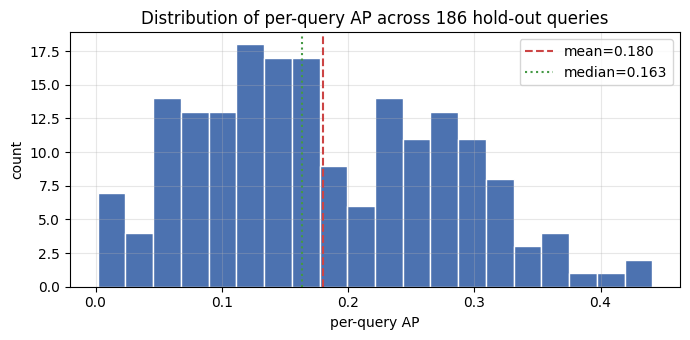

AP percentiles: p10=0.059 p50=0.163 p90=0.308
Queries with AP=0 (no relevant in top-50): 0/186
Queries with AP>0.5:                       0/186


In [6]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(results["AP"], bins=20, color="#4c72b0", edgecolor="white")
ax.set_xlabel("per-query AP"); ax.set_ylabel("count")
ax.set_title(f"Distribution of per-query AP across {len(results)} hold-out queries")
ax.axvline(results["AP"].mean(), color="#c44", linestyle="--", label=f"mean={results['AP'].mean():.3f}")
ax.axvline(results["AP"].median(), color="#494", linestyle=":", label=f"median={results['AP'].median():.3f}")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Numerical summary
print(f"AP percentiles: p10={results['AP'].quantile(0.1):.3f} p50={results['AP'].quantile(0.5):.3f} p90={results['AP'].quantile(0.9):.3f}")
print(f"Queries with AP=0 (no relevant in top-50): {(results['AP'] == 0).sum()}/{len(results)}")
print(f"Queries with AP>0.5:                       {(results['AP'] > 0.5).sum()}/{len(results)}")

**Interpretation guide.** If you see a *long left tail* of AP=0 queries plus a sparse right tail of AP>0.5 queries, that's the bimodality signature. Possible reads:

- A roll where every photo looks alike (e.g., a beach roll with 36 sunsets) → high-AP cluster.
- A roll where each photo is a different scene (a travel roll) → low-AP cluster, because the model has nothing roll-specific to grab onto.
- The mean averages over both and tells you neither.

If the histogram looks more like a single bump centred on the median, the eval is unimodal and the mean is a fair summary. **Either result is informative** — what matters is that you looked.

## Per-roll breakdown — which rolls score well?

Bimodality (if present) might be cohort-driven: *some rolls are uniformly easier, others uniformly harder*. Per-roll boxplot reveals it.

C:\Users\alfre\AppData\Local\Temp\ipykernel_36828\461899720.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=rolls, vert=True, patch_artist=True)


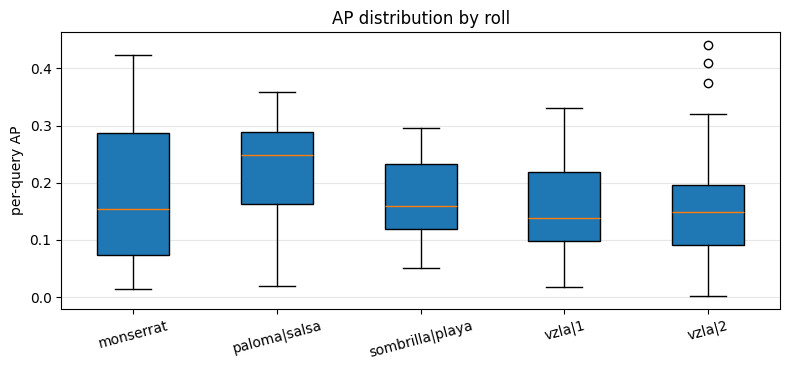

                  mean  median    std  count
roll                                        
monserrat        0.182   0.154  0.124     36
paloma|salsa     0.223   0.248  0.089     37
sombrilla|playa  0.168   0.160  0.069     37
vzla|1           0.159   0.139  0.080     36
vzla|2           0.168   0.149  0.105     40


In [7]:
fig, ax = plt.subplots(figsize=(8, 3.8))
rolls = sorted(results["roll"].unique())
groups = [results[results["roll"] == r]["AP"].to_numpy() for r in rolls]
ax.boxplot(groups, labels=rolls, vert=True, patch_artist=True)
ax.set_ylabel("per-query AP"); ax.set_title("AP distribution by roll")
ax.grid(True, axis="y", alpha=0.3)
for tick in ax.get_xticklabels(): tick.set_rotation(15)
plt.tight_layout(); plt.show()

# Per-roll summary
per_roll = results.groupby("roll")["AP"].agg(["mean", "median", "std", "count"]).round(3)
print(per_roll.to_string())

## Cross-reference with `03c` — does cohort density predict AP?

From `03c` (T1) we know each roll's mean intra-cohort cosine similarity in the un-augmented embedding space. **Prediction**: rolls with higher intra-cohort similarity should score higher AP here, because tightly-clustered rolls are easier to retrieve as a group.

If the prediction holds, the augmentation eval and the hold-out eval are giving you *consistent* signal. If it doesn't, they're measuring genuinely different things and you'd report both.

                 mean_intra_cos   mean_AP   n
cohort                                       
vzla|2                 0.071396  0.167563  40
monserrat              0.084140  0.182190  36
vzla|1                 0.099732  0.159236  36
sombrilla|playa        0.107040  0.167954  37
paloma|salsa           0.132358  0.222990  37


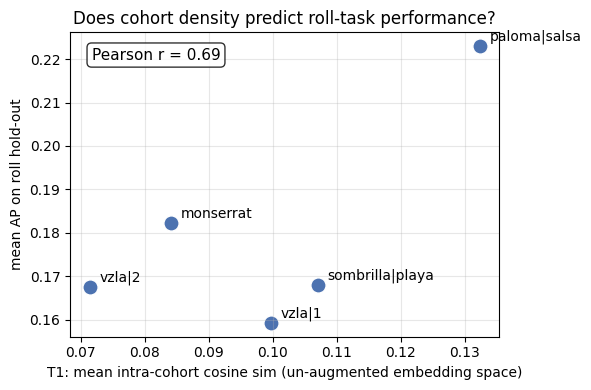

In [8]:
# Build cohort labels matching the embedding rows (NaN→'digital' for completeness)
cohorts = [
    p_to_r if not (isinstance(p_to_r, float) and np.isnan(p_to_r)) else "digital"
    for p_to_r in (path_to_roll.get(p) for p in all_paths)
]
t1 = intra_cohort_similarity(all_vecs, cohorts)
# Drop digital — it's not in this eval
t1_film = t1[t1["cohort"] != "digital"].set_index("cohort")

# Per-roll mean AP
per_roll_ap = results.groupby("roll")["AP"].mean()

# Join
joined = t1_film.join(per_roll_ap.rename("mean_AP"))
joined = joined[["mean_intra_cos", "mean_AP", "n"]].sort_values("mean_intra_cos")
print(joined.to_string())

# Scatter: density vs AP
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(joined["mean_intra_cos"], joined["mean_AP"], s=120, color="#4c72b0", edgecolor="white")
for roll, row in joined.iterrows():
    ax.annotate(roll, (row["mean_intra_cos"], row["mean_AP"]), xytext=(7, 4), textcoords="offset points", fontsize=10)
ax.set_xlabel("T1: mean intra-cohort cosine sim (un-augmented embedding space)")
ax.set_ylabel("mean AP on roll hold-out")
ax.set_title("Does cohort density predict roll-task performance?")
ax.grid(True, alpha=0.3)
if len(joined) >= 3:
    r = np.corrcoef(joined["mean_intra_cos"], joined["mean_AP"])[0, 1]
    ax.text(0.05, 0.95, f"Pearson r = {r:.2f}", transform=ax.transAxes, fontsize=11,
            verticalalignment="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
plt.tight_layout(); plt.show()

**Read the correlation.** If `r ≈ 0.7+`, cohort density is a *strong predictor* of roll-task performance, and the two evals are largely redundant — they both reward tight cohorts. If `r ≈ 0.3–0.5`, they're correlated but not identical: density helps, but isn't the whole story (composition of the rolls, semantic content, etc., matter too). If `r ≈ 0`, the two evals are measuring genuinely different things and you should report both as independent signals.

With only 5 rolls we don't have enough data points to get a tight estimate of `r` itself — but the *direction* is informative.

---

## Senior questions you can defend now

1. **"Leave-one-out vs leave-one-cohort-out — pick one and defend it."**  
   LOO: hold one *photo* out, eval against the rest. Measures within-cohort retrieval. LOCO: hold one *whole cohort* out, eval against the others. Measures cross-cohort generalisation. **They answer different product questions.** LOO is right if the user query is always within their existing library; LOCO is right if you're predicting performance on *unseen* rolls (e.g. uploading a new trip's worth of photos). For LUKI's product story (trip rediscovery within an existing library), LOO is the right choice.

2. **"How do you adjust for the fact that roll sizes vary wildly?"**  
   Per-query AP already does. AP is divided by `n_relevant`, which is per-query, so a roll with 36 mates and a roll with 5 mates contribute the same dynamic range to the metric. What you must NOT do is sum-then-average per-roll without weighting: that lets a single small roll punch above its weight in the headline number.

3. **"Your roll label is noisy. How noisy? Can you correct for it?"**  
   It's noisy in two specific ways: (a) some same-roll photos are visually unrelated (different subjects on one developer date) — false positives in the relevance label, which depress AP unjustly. (b) Some cross-roll photos are visually very similar (same beach, two different days) — false negatives, which depress AP unjustly. Estimating the noise rate would need human relevance labels — back to `03a`'s missing-data problem. Mitigations: report mAP **and** Recall@10 (Recall@10 is more tolerant to false-positive noise because it doesn't penalise low precision); or use a graded label scheme (NDCG over scores 0/1/2 if you can crowdsource them). For now we just *acknowledge* the noise out loud.

4. **"Is the per-query AP distribution unimodal or bimodal? What would each mean?"**  
   Read the histogram above. Bimodal → the eval is implicitly two evals stacked (easy roll-grouping cluster + hard roll-grouping cluster) and you should report each cluster's mean separately. Unimodal → mean is a fair summary. **Always check before quoting a single number.**

5. **"You ran 03c (augmentation) and 03d (roll hold-out). Are they redundant?"**  
   They measure overlapping but distinct properties. `03c` tests low-level invariance (does the model survive perturbation?). `03d` tests perceptual grouping (does the model cluster what humans cluster?). The cohort-density cross-reference above quantifies the overlap: high `r` means the two metrics largely co-vary; low `r` means they're independent angles. Report both unless `r` is near 1.

---

## What we'll productivize next

- `src/luki/eval/queries.py::build_holdout_task` — extends the existing module; `group_col` arg lets the same code serve both *roll* and (if you ever add session metadata) *session* hold-out.
- `src/luki/eval/runner.py` — generic `evaluate_holdout(eval_set, embeddings, group_col, top_k) -> DataFrame`. Brute-force cosine, no Qdrant. **Same runner reused in `03e`** when we swap embeddings for CLIP/SigLIP.
- `tests/test_runner.py` — tiny synthetic embedding matrix + tiny manifest, verify metrics line up with hand-computed expectations.

Say the word and I'll lift it.